# Завдання №1(№2)
## Імпортую необхідні бібліотеки для завантаження датасету

In [63]:
import pandas as pd
import numpy as np

##  Обрав,завантажив унікальний датасет та зробив Data Cleaning

In [62]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
print(f"Загальна кількість пропусків після: {df.isnull().sum().sum()}")
print(f"\n Перші 3 рядки після очищення:")
print(df.head(3))

Загальна кількість пропусків після: 0

 Перші 3 рядки після очищення:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  


# Завдання №3
## Побудував графіки залежності одного  атрибута від іншого (lineplot, scatterplott countplot).

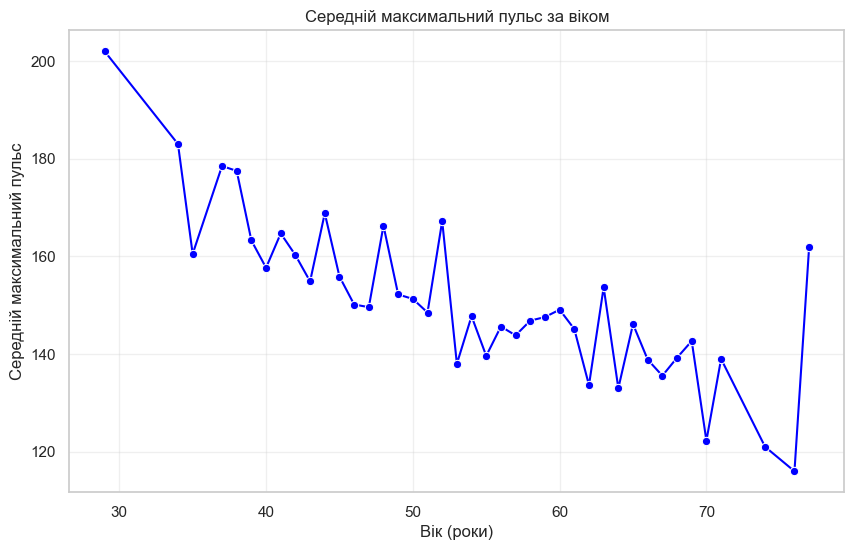

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
age_grouped = df.groupby('age')['thalach'].mean().reset_index()
plt.figure()
sns.lineplot(data=age_grouped, x='age', y='thalach', marker='o', color='blue')
plt.title('Середній максимальний пульс за віком')
plt.xlabel('Вік (роки)')
plt.ylabel('Середній максимальний пульс')
plt.grid(True, alpha=0.3)
plt.show()

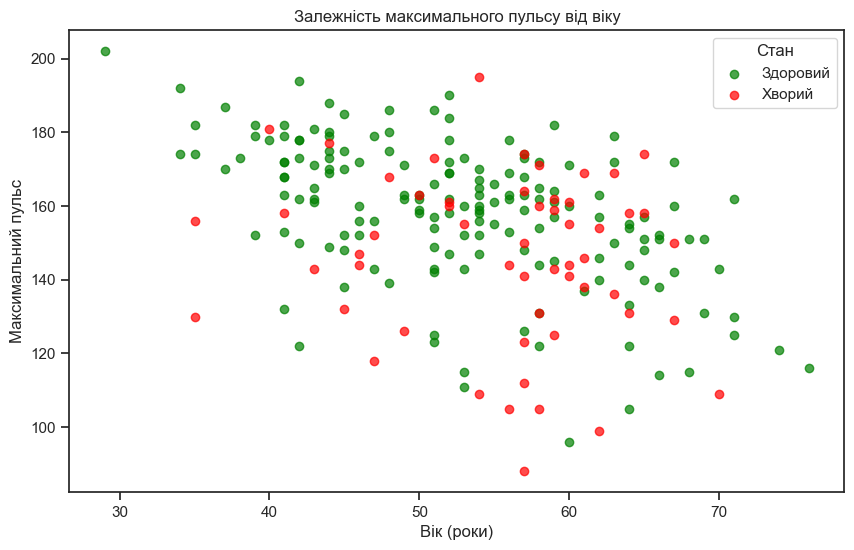

In [60]:
df['target_name'] = df['target'].map({0: 'Здоровий', 1: 'Хворий'})
plt.figure(figsize=(10, 6))
healthy = df[df['target'] == 0]
sick = df[df['target'] == 1]
plt.scatter(healthy['age'], healthy['thalach'], c='green', label='Здоровий', alpha=0.7)
plt.scatter(sick['age'], sick['thalach'], c='red', label='Хворий', alpha=0.7)
plt.title('Залежність максимального пульсу від віку')
plt.xlabel('Вік (роки)')
plt.ylabel('Максимальний пульс')
plt.legend(title='Стан')
plt.show()

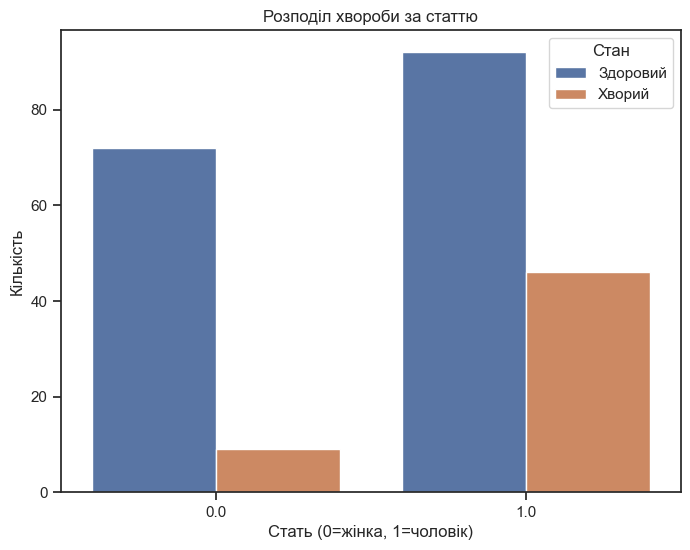

In [59]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sex', hue='target_name')
plt.title('Розподіл хвороби за статтю')
plt.xlabel('Стать (0=жінка, 1=чоловік)')
plt.ylabel('Кількість')
plt.legend(title='Стан')
plt.show()

# Завдання №4
## Побудував гістограму, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах

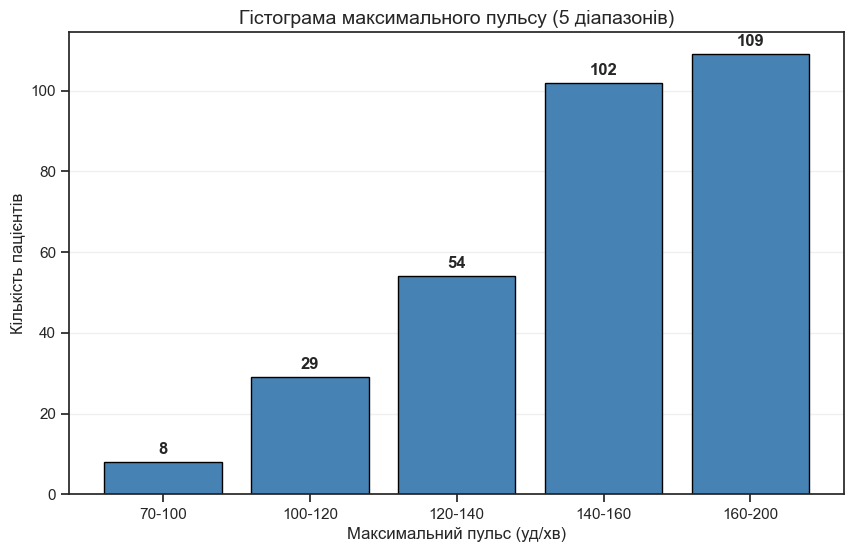

In [58]:
bins = [70, 100, 120, 140, 160, 200]
labels = ['70-100', '100-120', '120-140', '140-160', '160-200']
df['thalach_group'] = pd.cut(df['thalach'], bins=bins, labels=labels)
counts = df['thalach_group'].value_counts().reindex(labels)
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color='steelblue', edgecolor='black')
plt.title('Гістограма максимального пульсу (5 діапазонів)', fontsize=14)
plt.xlabel('Максимальний пульс (уд/хв)', fontsize=12)
plt.ylabel('Кількість пацієнтів', fontsize=12)
plt.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(count), ha='center', fontsize=12, fontweight='bold')
plt.show()

# Завдання №5
## Збудував графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 

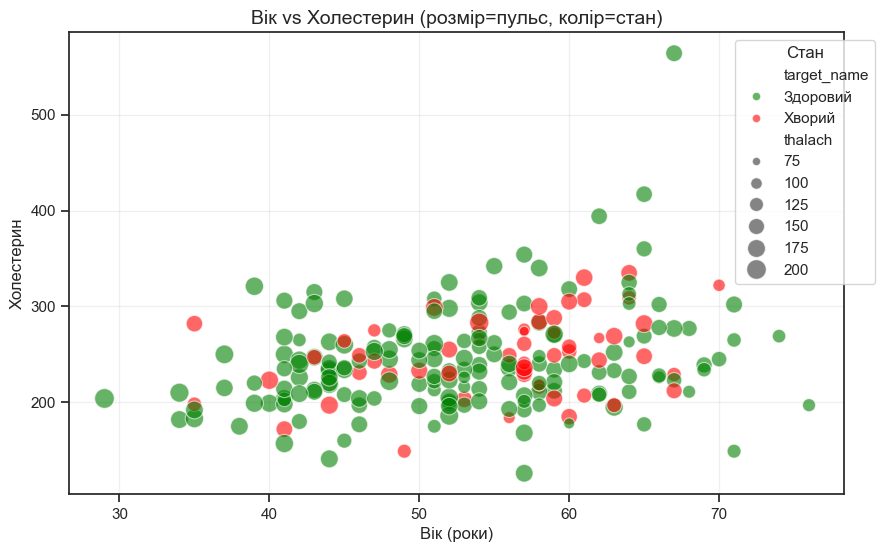

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='chol', 
                hue='target_name',
                size='thalach', sizes=(30, 200),
                palette={'Здоровий': 'green', 'Хворий': 'red'},
                alpha=0.6)
plt.title('Вік vs Холестерин (розмір=пульс, колір=стан)', fontsize=14)
plt.xlabel('Вік (роки)', fontsize=12)
plt.ylabel('Холестерин', fontsize=12)
plt.legend(title='Стан', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()

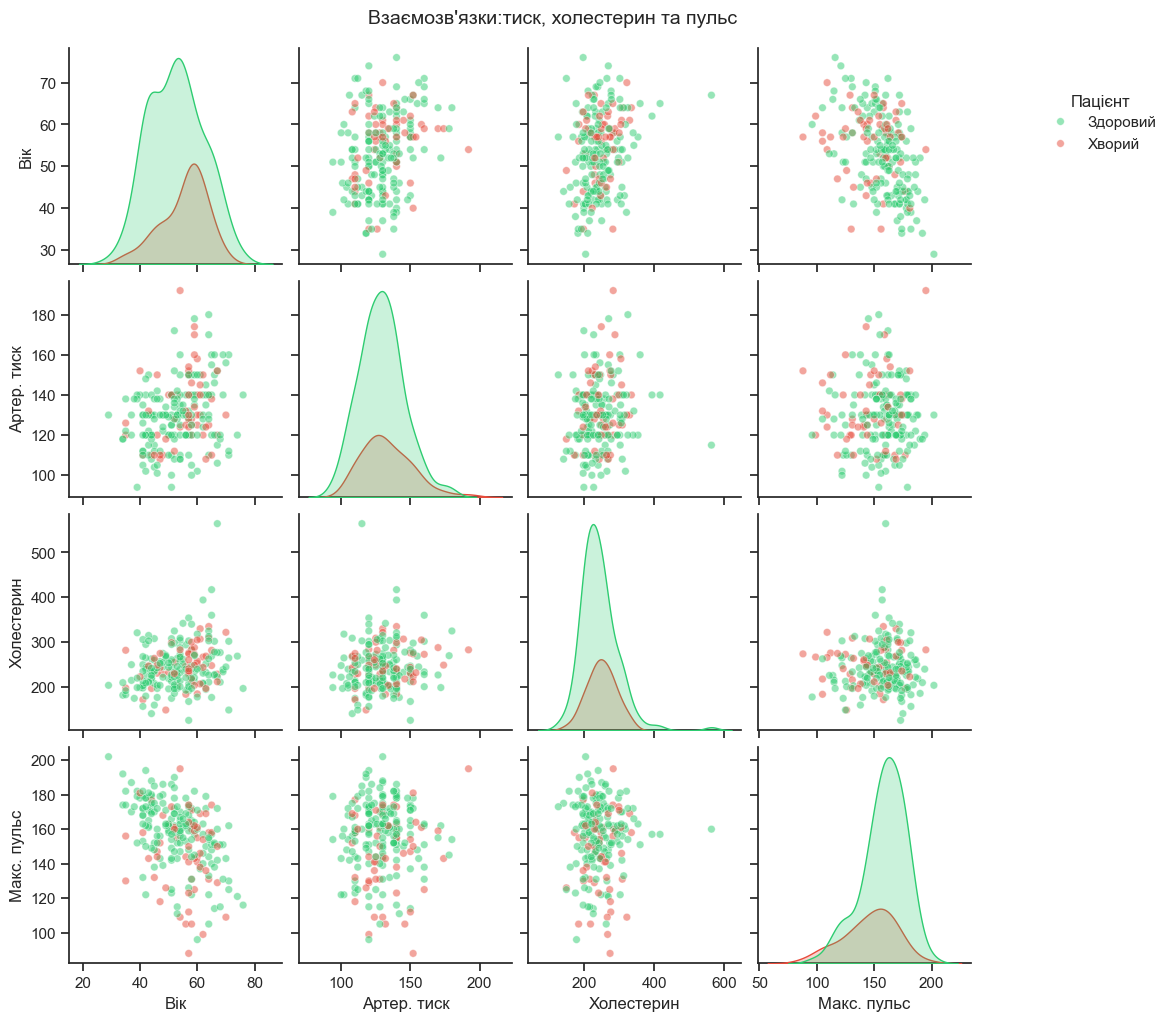

In [56]:
sns.set_theme(style="ticks")
plot_df = df[['age', 'trestbps', 'chol', 'thalach', 'target']].copy()
plot_df.columns = ['Вік', 'Артер. тиск', 'Холестерин', 'Макс. пульс', 'Діагноз']
plot_df['Діагноз'] = plot_df['Діагноз'].map({0: 'Здоровий', 1: 'Хворий'})
g = sns.pairplot(plot_df, hue='Діагноз', palette={'Здоровий': "#2ecc71", 'Хворий': "#e74c3c"},diag_kind="kde",
plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'w', 'linewidth': 0.5}
)
g.fig.suptitle('Взаємозв\'язки:тиск, холестерин та пульс', fontsize=14, y=1.02)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.05, 0.95), title='Пацієнт')
plt.show()

# Завдання №6
## Побудував інші графіки, що покажуть корисну інформацію про датасет.
## Інформацію брав звідси: https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57

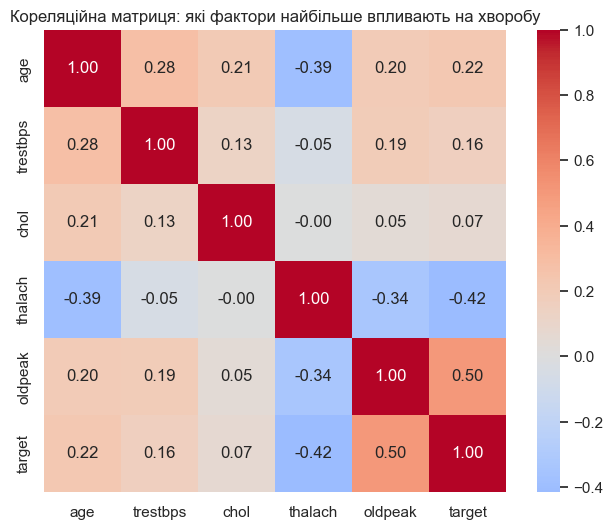

In [64]:
plt.figure(figsize=(8, 6))
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Кореляційна матриця: які фактори найбільше впливають на хворобу')
plt.show()

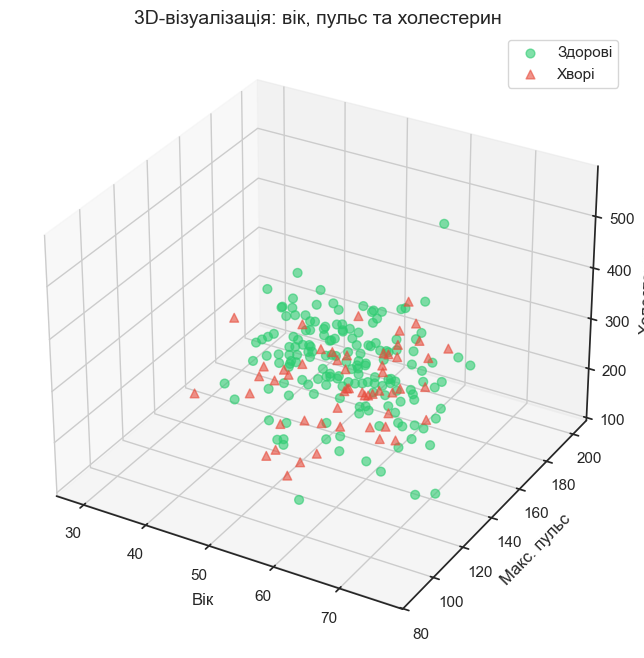

In [54]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
healthy = df[df['target'] == 0]
sick = df[df['target'] == 1]
ax.scatter(healthy['age'], healthy['thalach'], healthy['chol'], 
           c='#2ecc71', marker='o', label='Здорові', alpha=0.6, s=40)
ax.scatter(sick['age'], sick['thalach'], sick['chol'], 
           c='#e74c3c', marker='^', label='Хворі', alpha=0.6, s=40)
ax.set_xlabel('Вік', fontsize=12)
ax.set_ylabel('Макс. пульс', fontsize=12)
ax.set_zlabel('Холестерин', fontsize=12)
ax.set_title('3D-візуалізація: вік, пульс та холестерин', fontsize=14)
ax.legend()
plt.show()